In [1]:
import optuna
from optuna.samplers import RandomSampler, TPESampler, CmaEsSampler, PartialFixedSampler, NSGAIISampler, MOTPESampler, IntersectionSearchSpace, intersection_search_space
from optuna.trial import TrialState

from optuna.visualization import plot_contour
from optuna.visualization import plot_edf
from optuna.visualization import plot_intermediate_values
from optuna.visualization import plot_optimization_history
from optuna.visualization import plot_parallel_coordinate
from optuna.visualization import plot_param_importances
from optuna.visualization import plot_pareto_front
from optuna.visualization import plot_slice

c:\ProgramData\Anaconda3\envs\ai\lib\site-packages\numpy\_distributor_init.py:30: UserWarning: loaded more than 1 DLL from .libs:
c:\ProgramData\Anaconda3\envs\ai\lib\site-packages\numpy\.libs\libopenblas.FB5AE2TYXYH2IJRDKGDGQ3XBKLKTF43H.gfortran-win_amd64.dll
c:\ProgramData\Anaconda3\envs\ai\lib\site-packages\numpy\.libs\libopenblas.XWYDX2IKJW2NMTWSFYNGFUWKQU3LYTCZ.gfortran-win_amd64.dll
  warnings.warn("loaded more than 1 DLL from .libs:"
c:\ProgramData\Anaconda3\envs\ai\lib\site-packages\scipy\__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.2
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
grid = []
random = []
fin = []

In [3]:
pin=0

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.model_selection import train_test_split

def objective(trial):
        X, y = make_regression(n_features=5,n_informative=2,random_state=0, shuffle=False)
        X_train, X_valid, y_train, y_valid = train_test_split(X, y, test_size=0.2, random_state=0)
        n_est   = trial.suggest_int("n_estimators",100,1000)
        max_dep = trial.suggest_int("max_depth",2,1000)
        split   = trial.suggest_int("split",2,10)
        select_feature = trial.suggest_categorical("select_feature",["sqrt", "log2"])
        clf = RandomForestRegressor(n_estimators=n_est, max_depth=max_dep, 
                                        min_samples_split=split, 
                                        max_features = select_feature,
                                        random_state=42)
        clf.fit(X_train, y_train)
        if trial.should_prune():
                raise optuna.TrialPruned()
        if pin == 0:
                grid.append(clf.score(X_valid,y_valid))
        elif pin ==1:
                random.append(clf.score(X_valid,y_valid))
        elif pin ==2:
                fin.append(clf.score(X_valid,y_valid))
        mse = mean_squared_error(y_valid, clf.predict(X_valid), squared=True)
        return mse

In [5]:
Trial = 100

In [6]:
storage = optuna.storages.RDBStorage(url="sqlite:///example.db", engine_kwargs={"connect_args": {"timeout": 10000}})

In [7]:
pin = 0
grid.clear()
optuna.delete_study(study_name="Grid", storage="sqlite:///example.db")
search_space = {"n_estimators"  : [100,1000], 
                "max_depth"     : [2,100],
                "split"         : [2,10],
                "select_feature": ["sqrt", "log2"]
                }
study_gr = optuna.create_study(study_name="Grid",sampler=optuna.samplers.GridSampler(search_space),storage=storage,load_if_exists=True)
study_gr.optimize(objective, n_trials=Trial)

[I 2022-08-25 23:57:23,971] A new study created in RDB with name: Grid
[I 2022-08-25 23:57:25,072] Trial 0 finished with value: 2995.226569409445 and parameters: {'n_estimators': 100, 'max_depth': 100, 'split': 2, 'select_feature': 'sqrt'}. Best is trial 0 with value: 2995.226569409445.
[I 2022-08-25 23:57:25,781] Trial 1 finished with value: 5954.755161415977 and parameters: {'n_estimators': 100, 'max_depth': 2, 'split': 2, 'select_feature': 'log2'}. Best is trial 0 with value: 2995.226569409445.
[I 2022-08-25 23:57:27,518] Trial 2 finished with value: 3735.0115292018318 and parameters: {'n_estimators': 1000, 'max_depth': 100, 'split': 10, 'select_feature': 'log2'}. Best is trial 0 with value: 2995.226569409445.
[I 2022-08-25 23:57:29,498] Trial 3 finished with value: 2998.3869226396214 and parameters: {'n_estimators': 1000, 'max_depth': 100, 'split': 2, 'select_feature': 'sqrt'}. Best is trial 0 with value: 2995.226569409445.
[I 2022-08-25 23:57:31,441] Trial 4 finished with value: 6

In [8]:
pin=1
random.clear()
optuna.delete_study(study_name="Random", storage="sqlite:///example.db")
study_rd = optuna.create_study(study_name="Random",sampler=RandomSampler(),storage=storage,load_if_exists=True)
study_rd.optimize(objective, n_trials=Trial)

[I 2022-08-25 23:57:42,938] A new study created in RDB with name: Random
[I 2022-08-25 23:57:44,705] Trial 0 finished with value: 2926.5545536058266 and parameters: {'n_estimators': 972, 'max_depth': 10, 'split': 3, 'select_feature': 'sqrt'}. Best is trial 0 with value: 2926.5545536058266.
[I 2022-08-25 23:57:46,150] Trial 1 finished with value: 3347.8847133563613 and parameters: {'n_estimators': 904, 'max_depth': 244, 'split': 7, 'select_feature': 'sqrt'}. Best is trial 0 with value: 2926.5545536058266.
[I 2022-08-25 23:57:47,912] Trial 2 finished with value: 3201.82341714943 and parameters: {'n_estimators': 943, 'max_depth': 694, 'split': 6, 'select_feature': 'log2'}. Best is trial 0 with value: 2926.5545536058266.
[I 2022-08-25 23:57:49,314] Trial 3 finished with value: 3198.884301376737 and parameters: {'n_estimators': 977, 'max_depth': 72, 'split': 6, 'select_feature': 'log2'}. Best is trial 0 with value: 2926.5545536058266.
[I 2022-08-25 23:57:50,901] Trial 4 finished with value:

In [9]:
pin=2
fin.clear()
# optuna.delete_study(study_name="Bayesian", storage="sqlite:///example.db")
# study_fin = optuna.create_study(study_name="Bayesian",direction="minimize",storage=storage,pruner=optuna.pruners.SuccessiveHalvingPruner(),load_if_exists=True)
study_fin = optuna.create_study(study_name="Bayesian",direction="minimize",pruner=optuna.pruners.SuccessiveHalvingPruner(),load_if_exists=True)
study_fin.optimize(objective, n_trials=Trial)

[I 2022-08-25 23:59:27,896] A new study created in memory with name: Bayesian
[I 2022-08-25 23:59:28,447] Trial 0 finished with value: 3835.69942739541 and parameters: {'n_estimators': 189, 'max_depth': 268, 'split': 10, 'select_feature': 'sqrt'}. Best is trial 0 with value: 3835.69942739541.
[I 2022-08-25 23:59:28,851] Trial 1 finished with value: 3091.116650057384 and parameters: {'n_estimators': 234, 'max_depth': 941, 'split': 2, 'select_feature': 'log2'}. Best is trial 1 with value: 3091.116650057384.
[I 2022-08-25 23:59:29,615] Trial 2 finished with value: 3754.1864290822086 and parameters: {'n_estimators': 581, 'max_depth': 49, 'split': 10, 'select_feature': 'log2'}. Best is trial 1 with value: 3091.116650057384.
[I 2022-08-25 23:59:30,261] Trial 3 finished with value: 3461.1696700058237 and parameters: {'n_estimators': 562, 'max_depth': 42, 'split': 8, 'select_feature': 'log2'}. Best is trial 1 with value: 3091.116650057384.
[I 2022-08-25 23:59:31,600] Trial 4 finished with valu

C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_22916\3506693921.py:1: ExperimentalWarning: plot_edf is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_edf([study_gr, study_rd, study_fin]) #, target_name="minNum")


<AxesSubplot:title={'center':'Empirical Distribution Function Plot'}, xlabel='Objective Value', ylabel='Cumulative Probability'>

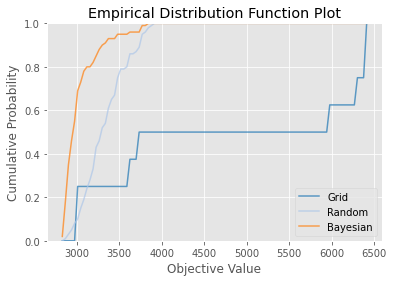

In [10]:
optuna.visualization.matplotlib.plot_edf([study_gr, study_rd, study_fin]) #, target_name="minNum")

In [11]:
len(grid), len(random), len(fin)

(16, 100, 100)

In [12]:
import numpy as np
np.max(grid),np.max(random),np.max(fin)

(0.8145276314875234, 0.8236354694207804, 0.8246353188935891)

In [13]:
if pin==2:
    [grid.append(0) for _ in range(len(fin)-len(grid))]
    pin=0
else:
    pass
xinput=[]
[xinput.append(i) for i in range(len(fin))]
len(grid)

100

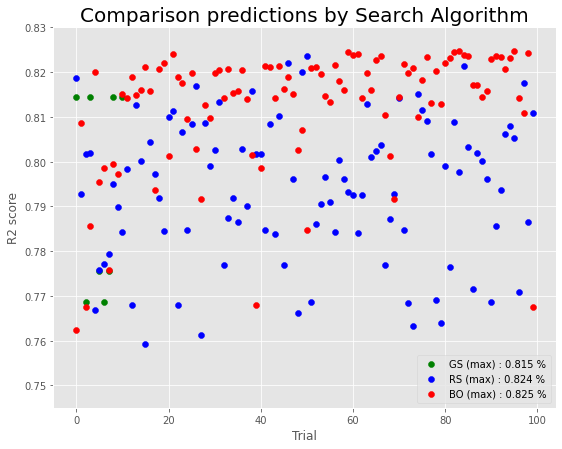

In [14]:
import matplotlib.pyplot as plt
gmax = np.max(grid)
rmax = np.max(random)
fmax = np.max(fin)
x1pos = grid.index(gmax)
x2pos = random.index(rmax)
x3pos = fin.index(fmax)
xmax1 = xinput[x1pos]
xmax2 = xinput[x2pos]
xmax3 = xinput[x3pos]

fig, ax = plt.subplots(figsize=[9, 7])
ax.scatter(xinput, grid, marker='o', label='GS (max) : %.3f %%' % (np.max(grid)),c='g')
# ax.annotate('GS Max : {:.5f}'.format(gmax), xy=(xmax1, gmax), xytext=(xmax1, gmax),
#             arrowprops=dict(facecolor='black', shrink=0.01),
#             )
ax.scatter(xinput, random, marker='o', label='RS (max) : %.3f %%' % (np.max(random)),c='b')
# ax.annotate('RS Max : {:.5f}'.format(rmax), xy=(xmax2, rmax), xytext=(xmax2, rmax),
#             arrowprops=dict(facecolor='black', shrink=0.01),
#             )
ax.scatter(xinput, fin, marker='o', label='BO (max) : %.3f %%' % (np.max(fin)),c='r')
# ax.annotate('BO Max : {:.5f}'.format(fmax), xy=(xmax3, fmax), xytext=(xmax3, fmax),
#             arrowprops=dict(facecolor='black', shrink=0.001),
#             )
ax.set_xlabel('Trial')
ax.set_ylabel('R2 score')
plt.ylim([0.745, 0.83])
plt.legend(loc=4)
plt.title("Comparison predictions by Search Algorithm", fontsize=20)
plt.savefig("0_Search_compare.png",dpi=300)
plt.show()

C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\407206075.py:1: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study_gr, params=["n_estimators", "max_depth"], target_name="minNum")
C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\407206075.py:2: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study_rd, params=["n_estimators", "max_depth"], target_name="minNum")
C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\407206075.py:3: ExperimentalWarning: plot_slice is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_slice(study_fin, params=["n_estimators", "max_depth"], target_name="minNum")


array([<AxesSubplot:xlabel='max_depth', ylabel='minNum'>,
       <AxesSubplot:xlabel='n_estimators'>], dtype=object)

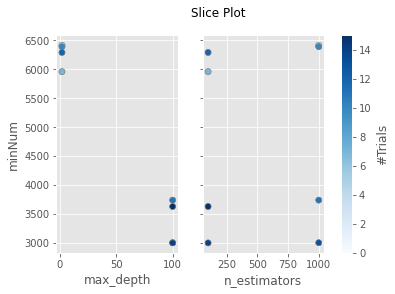

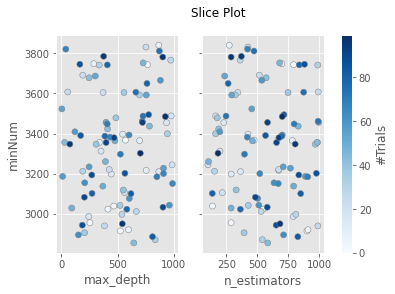

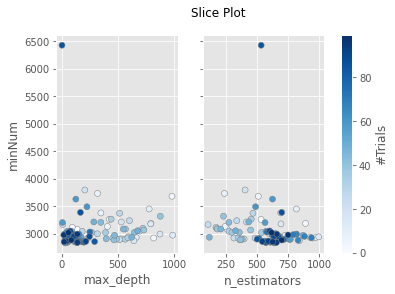

In [125]:
optuna.visualization.matplotlib.plot_slice(study_gr, params=["n_estimators", "max_depth"], target_name="minNum")
optuna.visualization.matplotlib.plot_slice(study_rd, params=["n_estimators", "max_depth"], target_name="minNum")
optuna.visualization.matplotlib.plot_slice(study_fin, params=["n_estimators", "max_depth"], target_name="minNum")

C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\229988472.py:1: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study_gr,  params=["n_estimators", "max_depth"], target_name="minNum")
[W 2022-08-25 12:02:17,292] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.
C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\229988472.py:2: ExperimentalWarning: plot_contour is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_contour(study_rd,  params=["n_estimators", "max_depth"], target_name="minNum")
[W 2022-08-25 12:02:21,712] Output figures of this Matplotlib-based `plot_contour` function would be different from those of the Plotly-based `plot_contour`.
C:\Users\LeeSJin\AppData\Local\Temp\ipykernel_4388\229988472.py:3: ExperimentalWarni

<AxesSubplot:title={'center':'Contour Plot'}, xlabel='n_estimators', ylabel='max_depth'>

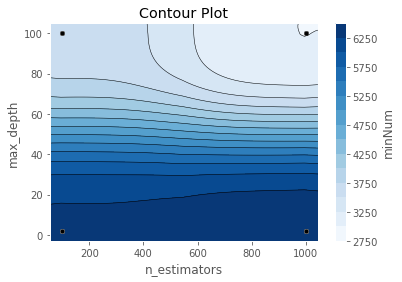

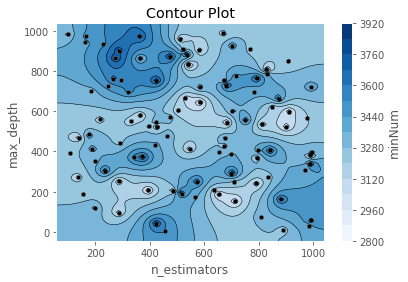

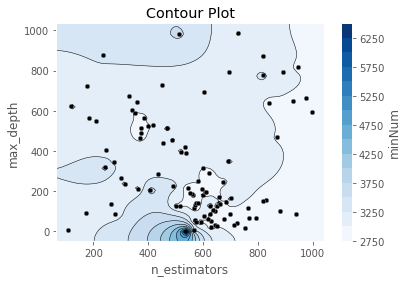

In [126]:
optuna.visualization.matplotlib.plot_contour(study_gr,  params=["n_estimators", "max_depth"], target_name="minNum")
optuna.visualization.matplotlib.plot_contour(study_rd,  params=["n_estimators", "max_depth"], target_name="minNum")
optuna.visualization.matplotlib.plot_contour(study_fin, params=["n_estimators", "max_depth"], target_name="minNum")